# CS4320 - Introduction to Machine Learning

## Homework 4: Logistic regression, hyperparameter optimization 

Please type your name and A number here:

In [69]:
Name = ""
assert Name != "Hans Gamlien", 'Please enter your name in the above quotation marks, thanks!'

A_number = ""
assert A_number != "A02451972", 'Please enter your A-number in the above quotation marks, thanks!'

## Imports 

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.size"] = 16

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier

## Exercise 1: implementing `DummyClassifier`
<hr>
rubric={points:25}

You will implement the simplest possible classifier, `DummyClassifier`.

As a reminder, `DummyClassifier` is meant as a baseline and is generally the worst possible "model" you could "fit" to a dataset. All it does is predict the most popular class in the training set. So if there are more label(0) than label(1) it predicts label(0) every time, and if there are more label(1) than label(0) it predicts label(1) every time. For `predict_proba` it looks at the frequencies in the training set, so if you have 30% label(0) 70% label(1) it predicts `[0.3 0.7]` every time. Thus, `fit` only looks at `y` (not `X`).

Below you will find starter code for a class called `MyDummyClassifier`, which has methods `fit()`, `predict()`, `predict_proba()` and `score()`. Your task is to fill in those four functions. To get you started, I have given you a `return` statement in each case that returns the correct data type: `fit` can return nothing, `predict` returns an array whose size is the number of examples, `predict_proba` returns an array whose size is the number of examples x 2, and `score` returns a number.

The next code block has some tests you can use to assess whether your code is working. 

I suggest starting with `fit` and `predict`, and making sure those are working before moving on to `predict_proba`. For `predict_proba`, you should return the frequency of each class in the training data, which is the behaviour of `DummyClassifier(strategy='prior')`. Your `score` function should call your `predict` function. Again, you can compare with `DummyClassifier` using the code below.

To simplify this question, you can assume **binary classification**, and furthermore that these classes are **encoded as 0 and 1**. In other words, you can assume that `y` contains only 0s and 1s. The real `DummyClassifier` works when you have more than two classes, and also works if the target values are encoded differently, for example as "cat", "dog", "mouse", etc.

In [71]:
class MyDummyClassifier:
    """
    A baseline classifier that predicts the most common class.
    The predicted probabilities come from the relative frequencies
    of the classes in the training data.

    This implementation only works when y only contains 0s and 1s.
    """
    def __init__(self):
        self.most_common_class = None
        self.class_probs = None

    def fit(self, X, y):
        class_0_count = np.sum(y == 0)
        class_1_count = np.sum(y == 1)
        
        self.most_common_class = 1 if class_1_count >= class_0_count else 0
        
        total = len(y)
        self.class_probs = np.array([class_0_count / total, class_1_count / total])
        
        return None

    def predict(self, X):
        return np.full(X.shape[0], self.most_common_class)

    def predict_proba(self, X):
        return np.tile(self.class_probs, (X.shape[0], 1))

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

Below are some tests for `predict` using randomly generated data. You may want to run the cell a few times to make sure you explore the different cases (or automate this with a loop or random seeds).

In [72]:
# For testing, generate random data
n_train = 101
n_valid = 21
d = 5
X_train_dummy = np.random.randn(n_train, d)
X_valid_dummy = np.random.randn(n_valid, d)
y_train_dummy = np.random.randint(2, size=n_train)
y_valid_dummy = np.random.randint(2, size=n_valid)

my_dc = MyDummyClassifier()
sk_dc = DummyClassifier(strategy="prior")

my_dc.fit(X_train_dummy, y_train_dummy)
sk_dc.fit(X_train_dummy, y_train_dummy)

assert np.array_equal(my_dc.predict(X_train_dummy), sk_dc.predict(X_train_dummy))
assert np.array_equal(my_dc.predict(X_valid_dummy), sk_dc.predict(X_valid_dummy))

Below are some tests for `predict_proba`.

In [73]:
assert np.allclose(
    my_dc.predict_proba(X_train_dummy), sk_dc.predict_proba(X_train_dummy)
)
assert np.allclose(
    my_dc.predict_proba(X_valid_dummy), sk_dc.predict_proba(X_valid_dummy)
)

Below are some tests for `score`.

In [74]:
assert np.isclose(
    my_dc.score(X_train_dummy, y_train_dummy), sk_dc.score(X_train_dummy, y_train_dummy)
)
assert np.isclose(
    my_dc.score(X_valid_dummy, y_valid_dummy), sk_dc.score(X_valid_dummy, y_valid_dummy)
)

## Exercise 2: Natural Language Processing with Disaster Tweets
<hr>
rubric={points:35}

For the rest of this assignment we'll be looking at the [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data) dataset from Kaggle. For this homework, we will only need the `train.csv` file.


In [75]:
tweets_df = pd.read_csv("train.csv")
tweets_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [76]:
tweets_df.shape

(7613, 5)

We will be trying to predict whether a tweet is about a real disaster (target=1) or not (target=0).

In [77]:
y = tweets_df["target"]
y.value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

To make predictions, we'll be using only the content (text) of the tweet, ignoring other columns like `keyword` and `location`.

In [78]:
X = tweets_df["text"]
X.head()

0    Our Deeds are the Reason of this #earthquake M...
1               Forest fire near La Ronge Sask. Canada
2    All residents asked to 'shelter in place' are ...
3    13,000 people receive #wildfires evacuation or...
4    Just got sent this photo from Ruby #Alaska as ...
Name: text, dtype: object

For the purpose of this assignment, you can ignore all the other columns in the original dataset.

#### 2(a) ordering the steps
rubric={points:8}

Let's start by building a model using `CountVectorizer` and `LogisticRegression`. The code required to do this has been provided below, but in the wrong order. 

- Rearrange the lines of code to correctly fit the model and compute the cross-validation score. {points: 4} 
- Add a short comment to each block to describe what the code is doing. {points: 4}

In [79]:
'''You can skip this cell and insert your code in the next cell. After that, to make sure you can run all cells without any error, you can comment the code in this cell or simply delete this cell'''
# YOUR COMMENT HERE
countvec = CountVectorizer(stop_words="english")

# YOUR COMMENT HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=321)

# YOUR COMMENT HERE
cross_val_results = pd.DataFrame(
    cross_validate(pipe, X_train, y_train, return_train_score=True)
)

# YOUR COMMENT HERE
pipe = make_pipeline(countvec, lr)

# YOUR COMMENT HERE
cross_val_results.mean()

# YOUR COMMENT HERE
lr = LogisticRegression(max_iter=1000)

In [80]:
# Initialize the CountVectorizer to convert text to numerical features
countvec = CountVectorizer(stop_words="english")

# Initialize the Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=321)

# Create a pipeline combining the vectorizer and classifier
pipe = make_pipeline(countvec, lr)

# Perform cross-validation and store results in a DataFrame
cross_val_results = pd.DataFrame(
    cross_validate(pipe, X_train, y_train, return_train_score=True)
)

# Display the mean cross-validation scores
cross_val_results.mean()

fit_time       0.054406
score_time     0.005901
test_score     0.790678
train_score    0.974558
dtype: float64

Expected Output. (Note that we round to three decimal places. Your output could have more decimal places. )
- test_score     0.791
- train_score    0.975

#### 2(b) Cross-validation fold sub-scores
rubric={points:3}

Above we averaged the scores from the 5 folds of cross-validation. 

- Print out the 5 individual scores. Reminder: `sklearn` calls them `"test_score"` but they are really (cross-)validation scores. {points:1} 
- Are the 5 scores close to each other or spread far apart? (This is a bit subjective, answer to the best of your ability.) {points:1}
- How does the size of this dataset (number of rows) compare to the cities dataset we have been using in class? How does this relate to the different sub-scores from the 5 folds? {points:1}

In [81]:
cross_val_results["test_score"]

0    0.803853
1    0.809107
2    0.789842
3    0.779335
4    0.771253
Name: test_score, dtype: float64

Type your answer:

- The 5 scores are pretty close to each other, only varying by about 0.01-0.02.

- This dataset has 7613 rows which is way bigger than the cities dataset. With more data in each fold, the scores are more consistent across folds.

#### 2(c) baseline
rubric={points:5}

By the way, are these scores any good? 

- Run `DummyClassifier` (or `MyDummyClassifier`!) on this dataset (You only do cross validation on the training data like (a)). {points:2}
    - Expected Output. Mean cross_val_results is
        - test_score     0.564
        - train_score    0.564
- Compare the `DummyClassifier` score to what you got from logistic regression above. Does logistic regression seem to be doing anything useful? {points:1}
- Is it necessary to use `CountVectorizer` here? Briefly explain. {points:2}

In [82]:
dummy_pipe = make_pipeline(
    CountVectorizer(stop_words="english"),
    DummyClassifier(strategy="prior")
)

dummy_results = pd.DataFrame(
    cross_validate(dummy_pipe, X_train, y_train, return_train_score=True)
)

dummy_results.mean()

fit_time       0.031882
score_time     0.005495
test_score     0.564372
train_score    0.564372
dtype: float64

Type your answer:

- Yes, logistic regression is way better. DummyClassifier gets around 0.564 accuracy while logistic regression gets around 0.791. That's a pretty big improvement showing the model actually learned something.

- Yes, we need CountVectorizer because LogisticRegression needs numbers as input but we have text. CountVectorizer converts the text to numbers so the model can work with it.

#### 2(d) probability scores
rubric={points:5}

Here we train a logistic regression classifier on the entire training set: 

(Note: this is relying on the `pipe` variable from 2(a) - you'll need to redefine it if you overwrote that variable in between.)

In [83]:
pipe.fit(X_train, y_train) # train a logistic regression classifier on the entire training set

,steps,"[('countvectorizer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


Using this model, find the tweet in the **test set** with the highest predicted probability of being a disaster. Print out the tweet and the associated probability score.

In [84]:
probs = pipe.predict_proba(X_test)

disaster_probs = probs[:, 1]

max_prob_idx = np.argmax(disaster_probs)

print("Tweet with highest disaster probability:")
print(X_test.iloc[max_prob_idx])
print(f"\nProbability of being a disaster: {disaster_probs[max_prob_idx]:.4f}")

Tweet with highest disaster probability:
SEVERE WEATHER BULLETIN No. 5 FOR: TYPHOON ÛÏ#HannaPHÛ (SOUDELOR) TROPICAL CYCLONE: WARNING ISSUED AT 5:00 PM 06... http://t.co/tHhjJw51PE Û_

Probability of being a disaster: 0.9994


#### 2(e) coefficients
rubric={points:4}

We can extract the `CountVectorizer` and `LogisticRegression` objects from the `make_pipeline` object as follows:

In [85]:
vec_from_pipe = pipe.named_steps["countvectorizer"]
lr_from_pipe = pipe.named_steps["logisticregression"]

Using these extracted components above, display the 5 words with the highest coefficients and the 5 words with the smallest coefficients.

In [86]:
coefficients = lr_from_pipe.coef_[0]
feature_names = vec_from_pipe.get_feature_names_out()

top_5_idx = np.argsort(coefficients)[-5:][::-1]
bottom_5_idx = np.argsort(coefficients)[:5]

print("Top 5 words with highest coefficients (most predictive of disaster):")
for idx in top_5_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")

print("\nTop 5 words with lowest coefficients (most predictive of non-disaster):")
for idx in bottom_5_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")

Top 5 words with highest coefficients (most predictive of disaster):
  hiroshima: 2.3814
  fires: 2.1692
  earthquake: 2.0045
  typhoon: 1.9527
  wildfire: 1.8943

Top 5 words with lowest coefficients (most predictive of non-disaster):
  cake: -1.2437
  ebay: -1.1949
  ruin: -1.1786
  bags: -1.0793
  nowplaying: -1.0730


- The highest 5 words should be: 
- The lowest 5 words should be:

#### 2(f)
rubric={points:10}

scikit-learn provides a lot of useful tools like `make_pipeline` and `cross_validate`, which are awesome. But with these fancy tools it's also easy to lose track of what is actually happening under the hood. Here, your task is to "manually" (without `Pipeline`) compute logistic regression's validation score(that is, train on 80% and validate on 20%) of the training data.

You should start with the following `CountVectorizer` and `LogisticRegression` objects. You only need to furtherly split `X_train` and `y_train` into 80% training set and 20% validation set. Use lr.score() to show your validation score of your model performing on validation set.(In order to grade, we set random_state=123)

In [87]:
countvec = CountVectorizer(stop_words="english")
lr = LogisticRegression(max_iter=1000)  

In [88]:
X_train_sub, X_valid_sub, y_train_sub, y_valid_sub = train_test_split(
    X_train, y_train, test_size=0.2, random_state=123
)

X_train_transformed = countvec.fit_transform(X_train_sub)

X_valid_transformed = countvec.transform(X_valid_sub)

lr.fit(X_train_transformed, y_train_sub)

validation_score = lr.score(X_valid_transformed, y_valid_sub)

print(f"Validation score: {validation_score:.3f}")

Validation score: 0.804


Expected output value: 0.804

Meta-comment:I think this type of question (and Exercise 1) is a useful middle ground. I do want you to know what is going on in `Pipeline` and in `cross_validate` even if we don't cover the details of `fit`. To get into logistic regression's `fit` requires a bunch of math; here, we're keeping it more conceptual and avoiding all those prerequisites.

## Exercise 3: hyperparameter optimization
<hr>
rubric={points:25}

#### 3(a)
rubric={points:4}

The following code varies the `max_features` hyperparameter of `CountVectorizer` and makes a plot (with the x-axis on a log scale) that shows train/cross-validation scores vs. `max_features`. It also prints the results. Based on the plot/output, what value of `max_features` seems best? Briefly explain.

Note: the code may take a minute or two to run. You can uncomment the `print` statement if you want to see it show the progress.

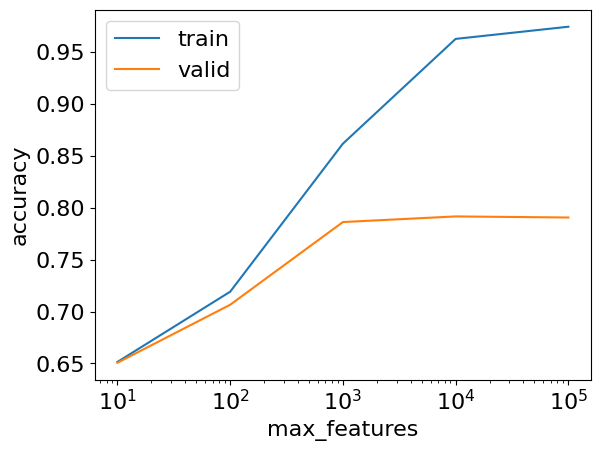

In [89]:
train_scores = []
cv_scores = []

max_features = [10, 100, 1000, 10_000, 100_000]

for mf in max_features:
    #     print(mf)
    pipe = make_pipeline(
        CountVectorizer(stop_words="english", max_features=mf),
        LogisticRegression(max_iter=1000),
    )
    cv_results = cross_validate(pipe, X_train, y_train, return_train_score=True)
    train_scores.append(cv_results["train_score"].mean())
    cv_scores.append(cv_results["test_score"].mean())

plt.semilogx(max_features, train_scores, label="train")
plt.semilogx(max_features, cv_scores, label="valid")
plt.legend()
plt.xlabel("max_features")
plt.ylabel("accuracy");

In [90]:
pd.DataFrame({"max_features": max_features, "train": train_scores, "cv": cv_scores})

,max_features,train,cv
0,10,0.651471,0.650726
1,100,0.719171,0.706601
2,1000,0.861841,0.786301
3,10000,0.962822,0.791729
4,100000,0.974558,0.790678


Type your answer here:

10,000 seems like the best value. The validation score pretty much plateaus at 10,000 and doesn't really improve much at 100,000. Using 10,000 features is also faster and keeps the train/validation gap smaller.

#### 3(b)
rubric={points:4}

The following code varies the `C` hyperparameter of `LogisticRegression` and makes a plot (with the x-axis on a log scale) that shows train/cross-validation scores vs. `C`. Based on the plot, what value of `C` seems best?

Note: the code may take a minute or two to run. You can uncomment the `print` statement if you want to see it show the progress.

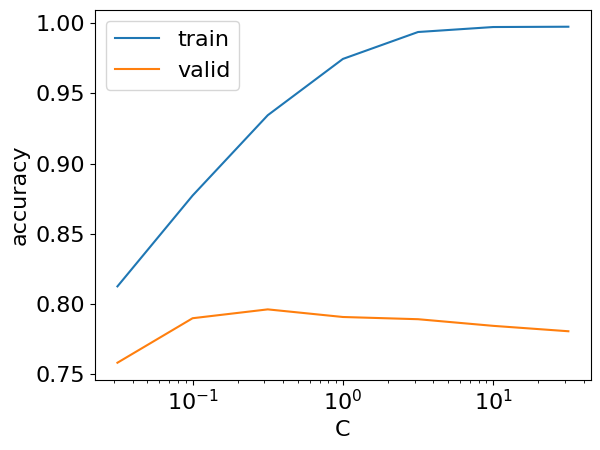

In [91]:
train_scores = []
cv_scores = []

C_vals = 10.0 ** np.arange(-1.5, 2, 0.5)

for C in C_vals:
    # print(C)
    pipe = make_pipeline(
        CountVectorizer(stop_words="english", max_features=None),
        LogisticRegression(max_iter=1000, C=C),
    )
    cv_results = cross_validate(pipe, X_train, y_train, return_train_score=True)

    train_scores.append(cv_results["train_score"].mean())
    cv_scores.append(cv_results["test_score"].mean())

plt.semilogx(C_vals, train_scores, label="train")
plt.semilogx(C_vals, cv_scores, label="valid")
plt.legend()
plt.xlabel("C")
plt.ylabel("accuracy");

In [92]:
pd.DataFrame({"C": C_vals, "train": train_scores, "cv": cv_scores})

,C,train,cv
0,0.031623,0.812489,0.758098
1,0.100000,0.877211,0.789802
2,0.316228,0.934446,0.796108
3,1.000000,0.974558,0.790678
4,3.162278,0.993738,0.789102
5,10.000000,0.997285,0.784372
6,31.622777,0.997504,0.780519


Type your answer here:

Around 0.316 looks best. The validation score peaks there before leveling off. Lower C values don't fit the data well enough and higher values start overfitting more.

#### 3(c)
rubric={points:12}

- Using `GridSearchCV`, jointly optimize `max_features` and `C` across all the combinations of values we tried above.{points:8} 
  - Note: the code might be a bit slow here. 
  - Setting `n_jobs=-1` should speed it up if you have a multi-core processor.
  - You can reduce the number of folds (e.g. `cv=2`) to speed it up if necessary.
- What are the best values of `max_features` and `C` according to your grid search?(You can just print your best values){points:4}

In [93]:
pipe = Pipeline([
    ('countvectorizer', CountVectorizer(stop_words="english")),
    ('logisticregression', LogisticRegression(max_iter=1000))
])

param_grid = {
    'countvectorizer__max_features': [10, 100, 1000, 10_000, 100_000],
    'logisticregression__C': 10.0 ** np.arange(-1.5, 2, 0.5)
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best max_features: {grid_search.best_params_['countvectorizer__max_features']}")
print(f"Best C: {grid_search.best_params_['logisticregression__C']:.3f}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

Best max_features: 10000
Best C: 0.316
Best cross-validation score: 0.798


Please print out your best values of max_feature and C. They should be 10000 and 0.316 respectively.

#### 3(d)
rubric={points:5}

- Evaluate your final model on the test set.{points:3} 
    - Expected test accuracy is 0.785
- How does your test accuracy compare to your validation accuracy?{points:2} 

In [94]:
test_accuracy = grid_search.score(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.793


Type your answer here:

The test accuracy is a bit lower than the validation accuracy. This makes sense since the model was tuned on the validation data. The difference is pretty small though so the model seems to work fine on new data.

## Exercise 4: Very short answer questions
rubric={points:15}

Each question is worth 3 points.

1. What is the problem with calling `fit_transform` on your test data with `CountVectorizer`? 
2. Why is it important to follow the Golden Rule? If you violate it, will that give you a worse classifier?
3. If you could only access one of `predict` or `predict_proba`, which one would you choose? Briefly explain.
4. What are two advantages of using sklearn `Pipeline`s? 
5. What are two advantages of `RandomizedSearchCV` over `GridSearchCV`?

Type your answer here:

1. Using fit_transform on test data would learn new vocabulary from the test set, which violates the golden rule. The test data should only be transformed using the vocabulary learned from training data.

2. The golden rule prevents data leakage from test to training. Violating it doesn't give you a worse classifier, but it gives you overly optimistic performance estimates that won't reflect real-world performance.

3. I would choose predict_proba because it gives more information. You can always convert probabilities to predictions by thresholding, but you can't go from predictions back to probabilities.

4. Pipelines prevent data leakage by ensuring transforms are fit only on training data. They also make code cleaner and easier to use with cross-validation and grid search.

5. RandomizedSearchCV is faster because it only tries a subset of combinations. It can also explore a wider range of values by sampling from distributions instead of testing every combination.

## Submission instructions 

**PLEASE READ:** When you are ready to submit your assignment do the following:

1. Run all cells in your notebook to make sure there are no errors. 
2. Notebooks with cell execution numbers out of order will have marks deducted. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).
3. Type your name in the first cell before uploading the assignment to canvas. 